<a href="https://colab.research.google.com/github/gangolaprithi79-collab/Aerial-Object-Classification-Detection/blob/main/Aerial_Object_Classification_%26_Detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Aerial Object Classification & Detection**

In [19]:
from google.colab import files
uploaded = files.upload()

ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 420, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 420, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Saving train-20260411T042710Z-3-001.zip to train-20260411T042710Z-3-001.zip


### Upload `test.zip`
Please upload the `test.zip` file. This will update the `uploaded` variable with its content.

In [20]:
from google.colab import files
uploaded_test = files.upload()

Saving test-20260411T042710Z-3-001.zip to test-20260411T042710Z-3-001.zip


### Upload `valid.zip`
Please upload the `valid.zip` file. This will update a new variable `uploaded_valid` with its content.

In [21]:
from google.colab import files
uploaded_valid = files.upload()

Saving valid-20260411T042714Z-3-001.zip to valid-20260411T042714Z-3-001.zip


### Unzip `valid.zip`
Now, let's unzip the `valid.zip` file into the `data/valid` directory. Similar to the previous steps, we'll write the uploaded content to a file on disk first, then proceed with unzipping it.

In [22]:
import zipfile
import os

def unzip_file(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

# Get the filename of the uploaded valid zip file
valid_zip_filename = list(uploaded_valid.keys())[0]

# Write the uploaded file to disk
with open(valid_zip_filename, 'wb') as f:
    f.write(uploaded_valid[valid_zip_filename])

# Unzip the valid file
unzip_file(valid_zip_filename, 'data/valid')

print(f"'{valid_zip_filename}' has been unzipped into 'data/valid'.")

'valid-20260411T042714Z-3-001.zip' has been unzipped into 'data/valid'.


In [ ]:
from google.colab import files
uploaded_test = files.upload()

Saving test-20260411T042710Z-3-001.zip to test-20260411T042710Z-3-001.zip


### Unzip `test.zip`
Now, let's unzip the `test.zip` file into the `data/test` directory. This will follow the same process as the training data: writing the uploaded content to a file on disk first, then unzipping it.

In [23]:
import zipfile
import os

def unzip_file(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

# Get the filename of the uploaded test zip file
test_zip_filename = list(uploaded_test.keys())[0]

# Write the uploaded file to disk
with open(test_zip_filename, 'wb') as f:
    f.write(uploaded_test[test_zip_filename])

# Unzip the test file
unzip_file(test_zip_filename, 'data/test')

print(f"'{test_zip_filename}' has been unzipped into 'data/test'.")

'test-20260411T042710Z-3-001.zip' has been unzipped into 'data/test'.


In [24]:
import zipfile
import os

def unzip_file(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

# Unzip datasets
train_zip_filename = list(uploaded.keys())[0]

# Write the uploaded file to disk
with open(train_zip_filename, 'wb') as f:
    f.write(uploaded[train_zip_filename])

unzip_file(train_zip_filename, 'data/train')
# unzip_file('valid.zip', 'data/valid') # These files are not yet uploaded
# unzip_file('test.zip', 'data/test') # These files are not yet uploaded

In [ ]:
for root, dirs, files in os.walk('data'):
    print(f"{root}: {len(files)} files")

data: 0 files
data/train: 0 files
data/train/train: 0 files
data/train/train/bird: 1414 files
data/train/train/drone: 1248 files
data/test: 0 files
data/test/test: 0 files
data/test/test/bird: 121 files
data/test/test/drone: 94 files
data/valid: 0 files
data/valid/valid: 0 files
data/valid/valid/bird: 217 files
data/valid/valid/drone: 225 files


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load datasets
train_dataset = datasets.ImageFolder('data/train/train', transform=transform)
valid_dataset = datasets.ImageFolder('data/valid/valid', transform=transform)
test_dataset  = datasets.ImageFolder('data/test/test', transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
print(train_dataset.classes)

['bird', 'drone']


In [ ]:
import torch
import torch.optim as optim
from sklearn.metrics import accuracy_score

# Instantiate the model. Assuming SimpleCNN class is defined in an earlier cell.
model = SimpleCNN()

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Hyperparameters
num_epochs = 10
learning_rate = 0.001

# Loss and optimizer
criterion = torch.nn.BCELoss() # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device) # Ensure labels are float and have shape (batch_size, 1)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {running_loss/len(train_loader):.4f}')

    # Validation phase
    model.eval() # Set the model to evaluation mode
    val_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad(): # No need to compute gradients during validation
        for images, labels in valid_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            predicted = (outputs >= 0.5).float() # Convert probabilities to binary predictions
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate validation accuracy
    val_accuracy = accuracy_score(all_labels, all_preds)

    print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss/len(valid_loader):.4f}, Validation Accuracy: {val_accuracy:.4f}')

print('Training complete!')

Epoch [1/10], Training Loss: 51.3733
Epoch [1/10], Validation Loss: 48.4375, Validation Accuracy: 0.5090
Epoch [2/10], Training Loss: 53.2490
Epoch [2/10], Validation Loss: 48.4375, Validation Accuracy: 0.5090
Epoch [3/10], Training Loss: 53.0878
Epoch [3/10], Validation Loss: 48.4375, Validation Accuracy: 0.5090
Epoch [4/10], Training Loss: 52.9266
Epoch [4/10], Validation Loss: 48.4375, Validation Accuracy: 0.5090
Epoch [5/10], Training Loss: 53.2490
Epoch [5/10], Validation Loss: 48.4375, Validation Accuracy: 0.5090
Epoch [6/10], Training Loss: 53.0878
Epoch [6/10], Validation Loss: 48.4375, Validation Accuracy: 0.5090
Epoch [7/10], Training Loss: 53.2490
Epoch [7/10], Validation Loss: 48.4375, Validation Accuracy: 0.5090
Epoch [8/10], Training Loss: 53.2490
Epoch [8/10], Validation Loss: 48.4375, Validation Accuracy: 0.5090
Epoch [9/10], Training Loss: 53.0878
Epoch [9/10], Validation Loss: 48.4375, Validation Accuracy: 0.5090
Epoch [10/10], Training Loss: 53.0878
Epoch [10/10], Va

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(64 * 56 * 56, 128) # (224 / 2 / 2 = 56)
        self.fc2 = nn.Linear(128, 1) # Output for binary classification

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 64 * 56 * 56) # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x)) # Sigmoid for binary classification output
        return x

# Instantiate the model
model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=200704, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


This `SimpleCNN` model consists of:

*   **Two Convolutional Layers (`conv1`, `conv2`)**: These layers extract features from the input images. Each is followed by a Batch Normalization layer (`bn1`, `bn2`) to stabilize training and a ReLU activation function.
*   **Two Max Pooling Layers (`pool`)**: These layers reduce the spatial dimensions of the feature maps, which helps to make the model more robust to variations in image position and reduces computational cost.
*   **Two Fully Connected Layers (`fc1`, `fc2`)**: After flattening the output from the convolutional layers, these dense layers perform classification. The final layer uses a `sigmoid` activation function to output a probability between 0 and 1, suitable for binary classification.

Classes: ['train']


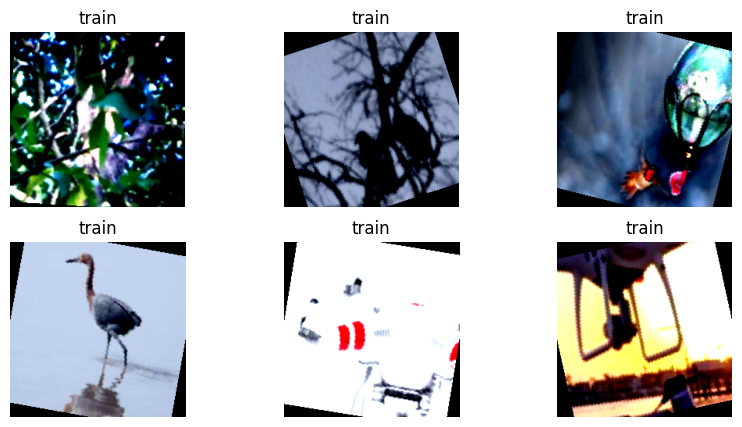

In [ ]:
# =========================
# 1. Import Libraries
# =========================
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =========================
# 2. Define Transforms
# =========================

# Train (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),   # crop + zoom
    transforms.RandomHorizontalFlip(),   # flip
    transforms.RandomRotation(20),       # rotation
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),                                   # brightness/contrast
    transforms.ToTensor(),               # [0,1]
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test (NO augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================
# 3. Load Datasets
# =========================

train_dataset = datasets.ImageFolder('data/train', transform=train_transform)
valid_dataset = datasets.ImageFolder('data/valid', transform=val_test_transform)
test_dataset  = datasets.ImageFolder('data/test',  transform=val_test_transform)

# =========================
# 4. Create DataLoaders
# =========================

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# =========================
# 5. Check Classes
# =========================
print("Classes:", train_dataset.classes)

# =========================
# 6. Visualize Augmented Images
# =========================

def imshow(img):
    img = img / 2 + 0.5  # unnormalize (approx)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

import numpy as np

# Get one batch
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    imshow(images[i])
    plt.title(train_dataset.classes[labels[i]])
plt.show()

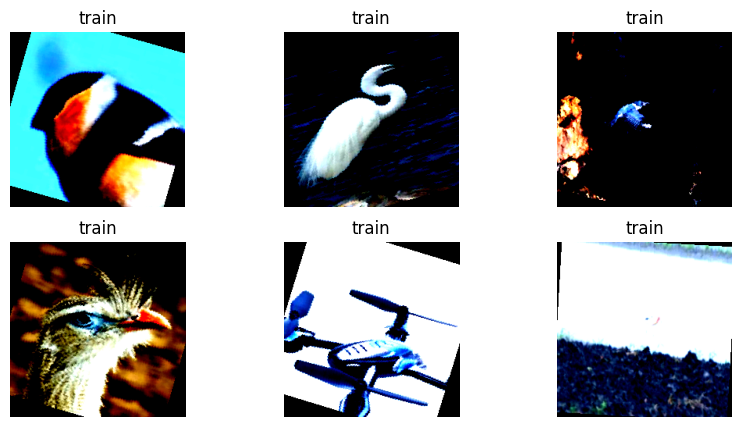

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(train_dataset.classes[labels[i]])
    plt.axis('off')
plt.show()

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 🔹 Train Transform (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),              # resize first
    transforms.RandomResizedCrop(224),          # cropping + zoom
    transforms.RandomHorizontalFlip(),          # flipping
    transforms.RandomRotation(20),              # rotation
    transforms.ColorJitter(                     # brightness, contrast
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),                      # converts to [0,1]
    transforms.Normalize(                       # normalization
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 🔹 Validation/Test Transform (NO augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_dataset = datasets.ImageFolder('data/train', transform=train_transform)
valid_dataset = datasets.ImageFolder('data/valid', transform=val_test_transform)
test_dataset  = datasets.ImageFolder('data/test',  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

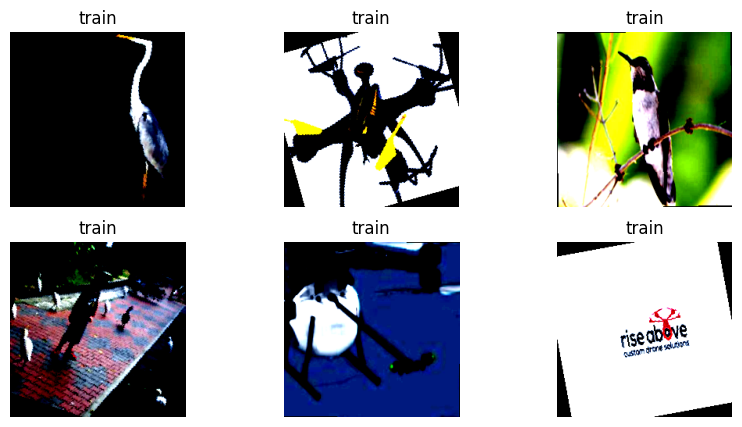

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(train_dataset.classes[labels[i]])
    plt.axis('off')
plt.show()

# **1. Custom CNN Model**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        # Conv Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        # Conv Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        # Conv Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        # Fully Connected
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, 2)  # 2 classes: bird, drone

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 224 → 112
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 112 → 56
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 56 → 28

        x = x.view(x.size(0), -1)  # flatten

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# Initialize model
model = CustomCNN()
print(model)

CustomCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)


# **Option A: ResNet18**

In [ ]:
from torchvision import models

model = models.resnet18(pretrained=True)

# Freeze base layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 2)

print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 227MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# **Option B: MobileNetV2**

In [ ]:
model = models.mobilenet_v2(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(model.last_channel, 2)

print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 131MB/s]


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

# **Option C: EfficientNet-B0**

In [ ]:
model = models.efficientnet_b0(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 160MB/s]

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

# **3. Loss Function + Optimizer**

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

# **4. Training Loop**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}")

Epoch [1/10], Loss: 6.1794
Epoch [2/10], Loss: 2.7048
Epoch [3/10], Loss: 2.0605
Epoch [4/10], Loss: 1.3389
Epoch [5/10], Loss: 1.2094
Epoch [6/10], Loss: 1.1566
Epoch [7/10], Loss: 0.6977
Epoch [8/10], Loss: 0.8181
Epoch [9/10], Loss: 0.6644
Epoch [10/10], Loss: 0.4848


# **5. Validation Accuracy**

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Validation Accuracy: {100 * correct / total:.2f}%")

Validation Accuracy: 99.77%


# **1. Setup (Metrics + Utilities)**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# **2. Early Stopping + Model Checkpoint**

In [ ]:
class EarlyStopping:
    def __init__(self, patience=3, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.counter = 0
        self.best_model = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
            self.counter = 0

# **3. Training Function (with Metrics)**

In [ ]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10):
    model.to(device)
    early_stopping = EarlyStopping(patience=3)

    for epoch in range(epochs):
        # ===== TRAIN =====
        model.train()
        train_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # ===== METRICS =====
        acc = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds)
        recall = recall_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")

        # ===== Early Stopping =====
        early_stopping(val_loss, model)

        if early_stopping.early_stop:
            print("Early stopping triggered!")
            break

    # Load best model
    model.load_state_dict(early_stopping.best_model)
    return model

# **4. Model Checkpoint (Save Best Model)**

In [ ]:
torch.save(model.state_dict(), "best_model.pth")

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

# **5. Train Custom CNN**

In [ ]:
model_cnn = CustomCNN()

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001)

model_cnn = train_model(model_cnn, train_loader, valid_loader, criterion, optimizer, epochs=15)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Epoch 1/15
Train Loss: 0.7970
Val Loss: 0.0000
Accuracy: 1.0000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Epoch 2/15
Train Loss: 0.0000
Val Loss: 0.0000
Accuracy: 1.0000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Epoch 13/15
Train Loss: 0.0000
Val Loss: 0.0000
Accuracy: 1.0000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Epoch 14/15
Train Loss: 0.0000
Val Loss: 0.0000
Accuracy: 1.0000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

Epoch 15/15
Train Loss: 0.0000
Val Loss: 0.0000
Accuracy: 1.0000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **6. Train Transfer Learning (ResNet18)**

In [ ]:
from torchvision import models
import torch.nn as nn

model_resnet = models.resnet18(pretrained=True)

for param in model_resnet.parameters():
    param.requires_grad = False

model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 2)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_resnet.parameters(), lr=0.001)

model_resnet = train_model(model_resnet, train_loader, valid_loader, criterion, optimizer, epochs=10)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classificat


Epoch 1/10
Train Loss: 2.5751
Val Loss: 0.0024
Accuracy: 1.0000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Epoch 2/10
Train Loss: 0.0118
Val Loss: 0.0022
Accuracy: 1.0000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Epoch 8/10
Train Loss: 0.0062
Val Loss: 0.0010
Accuracy: 1.0000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Epoch 9/10
Train Loss: 0.0050
Val Loss: 0.0009
Accuracy: 1.0000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

Epoch 10/10
Train Loss: 0.0057
Val Loss: 0.0008
Accuracy: 1.0000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **7. Final Test Evaluation**

In [ ]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    print("\nTest Metrics:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

# **1. Confusion Matrix + Classification Report**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_with_cm(model, test_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names,
                cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # Classification Report
    print("Classification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


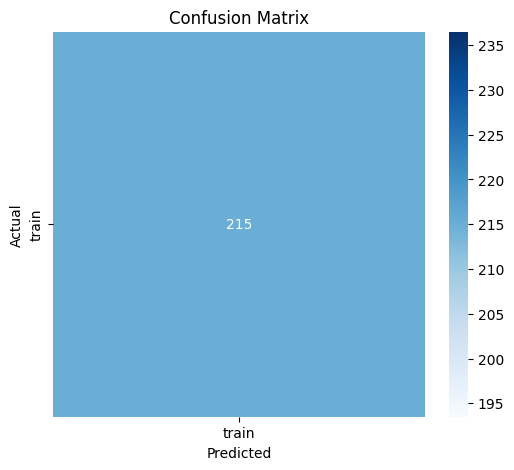

Classification Report:

              precision    recall  f1-score   support

       train       1.00      1.00      1.00       215

    accuracy                           1.00       215
   macro avg       1.00      1.00      1.00       215
weighted avg       1.00      1.00      1.00       215



In [ ]:
class_names = train_dataset.classes  # ['bird', 'drone']
evaluate_with_cm(model_resnet, test_loader, class_names)

# **2. Track Loss & Accuracy During Training**

In [ ]:
def train_model_with_history(model, train_loader, valid_loader, criterion, optimizer, epochs=10):
    model.to(device)

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # TRAIN
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # VALIDATION
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss / len(valid_loader)
        val_acc = correct / total

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    return model, train_losses, val_losses, val_accuracies

# **3. Plot Graphs**

In [ ]:
def plot_training_curves(train_losses, val_losses, val_accuracies):
    epochs = range(1, len(train_losses)+1)

    plt.figure(figsize=(12,5))

    # Loss Plot
    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy Plot
    plt.subplot(1,2,2)
    plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='green')
    plt.title('Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

Epoch 1: Train Loss=0.0000, Val Loss=0.0001, Val Acc=1.0000
Epoch 2: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 3: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 4: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 5: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 6: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 7: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 8: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 9: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 10: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000


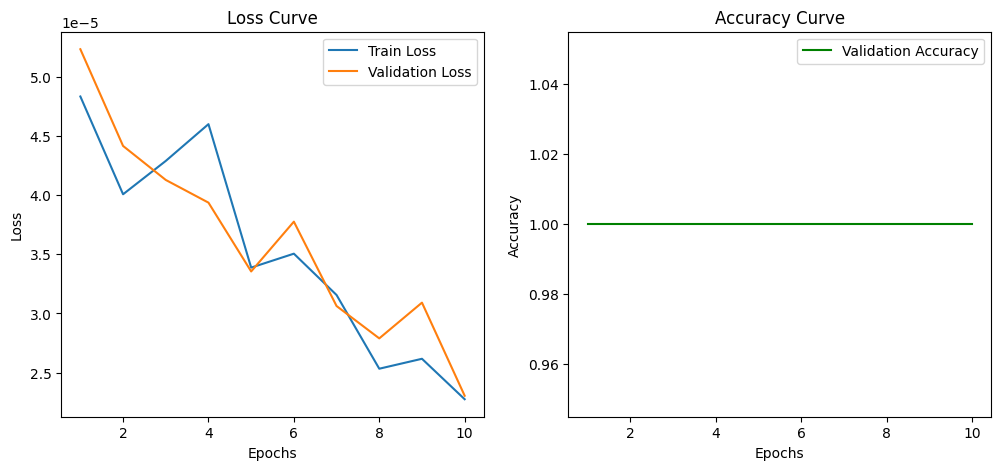

In [ ]:
model, train_losses, val_losses, val_accuracies = train_model_with_history(
    model_resnet, train_loader, valid_loader, criterion, optimizer, epochs=10
)

plot_training_curves(train_losses, val_losses, val_accuracies)

# **1. Compare Models (Custom CNN vs Transfer Learning)**

### **Training Multiple Models & Storing Results**

In [ ]:
import time

model_results = []

def train_and_evaluate(model, model_name):
    start_time = time.time()

    model, train_losses, val_losses, val_accuracies = train_model_with_history(
        model, train_loader, valid_loader, criterion, optimizer, epochs=10
    )

    end_time = time.time()
    training_time = end_time - start_time

    # Evaluate on test
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    model_results.append({
        "model": model_name,
        "accuracy": acc,
        "training_time": training_time,
        "model_obj": model
    })

    return model

### **Train Different Models**

In [ ]:
# Custom CNN
cnn_model = CustomCNN()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)
train_and_evaluate(cnn_model, "Custom CNN")

# ResNet18
resnet_model = models.resnet18(pretrained=True)
for param in resnet_model.parameters():
    param.requires_grad = False
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 2)

optimizer = torch.optim.Adam(resnet_model.parameters(), lr=0.001)
train_and_evaluate(resnet_model, "ResNet18")

# MobileNetV2
mobilenet_model = models.mobilenet_v2(pretrained=True)
for param in mobilenet_model.parameters():
    param.requires_grad = False
mobilenet_model.classifier[1] = nn.Linear(mobilenet_model.last_channel, 2)

optimizer = torch.optim.Adam(mobilenet_model.parameters(), lr=0.001)
train_and_evaluate(mobilenet_model, "MobileNetV2")

Epoch 1: Train Loss=0.0093, Val Loss=0.0000, Val Acc=1.0000
Epoch 2: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 3: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 4: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 5: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 6: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 7: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 8: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 9: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 10: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Train Loss=0.0347, Val Loss=0.0002, Val Acc=1.0000
Epoch 2: Train Loss=0.0001, Val Loss=0.0001, Val Acc=1.0000
Epoch 3: Train Loss=0.0001, Val Loss=0.0001, Val Acc=1.0000
Epoch 4: Train Loss=0.0001, Val Loss=0.0001, Val Acc=1.0000
Epoch 5: Train Loss=0.0001, Val Loss=0.0001, Val Acc=1.0000
Epoch 6: Train Loss=0.0001, Val Loss=0.0001, Val Acc=1.0000
Epoch 7: Train Loss=0.0001, Val Loss=0.0001, Val Acc=1.0000
Epoch 8: Train Loss=0.0001, Val Loss=0.0001, Val Acc=1.0000
Epoch 9: Train Loss=0.0001, Val Loss=0.0001, Val Acc=1.0000
Epoch 10: Train Loss=0.0001, Val Loss=0.0001, Val Acc=1.0000


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Train Loss=0.0155, Val Loss=0.0000, Val Acc=1.0000
Epoch 2: Train Loss=0.0001, Val Loss=0.0000, Val Acc=1.0000
Epoch 3: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000
Epoch 4: Train Loss=0.0001, Val Loss=0.0000, Val Acc=1.0000
Epoch 5: Train Loss=0.0000, Val Loss=0.0000, Val Acc=1.0000


# **2. Display Comparison**

In [ ]:
for result in model_results:
    print(f"Model: {result['model']}")
    print(f"Accuracy: {result['accuracy']:.4f}")
    print(f"Training Time: {result['training_time']:.2f} seconds")
    print("-" * 30)

# **3. Select Best Model Automatically**

In [ ]:
best_model_data = max(model_results, key=lambda x: x["accuracy"])

best_model = best_model_data["model_obj"]
print(f"Best Model: {best_model_data['model']}")
print(f"Best Accuracy: {best_model_data['accuracy']:.4f}")

# **4. Save Best Model (Deployment Ready)**

In [ ]:
torch.save(best_model.state_dict(), "best_model.pth")

# **5. Load Model Later (Important for Streamlit)**

In [ ]:
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

# **6. Streamlit Deployment (Simple App)**

In [ ]:
import streamlit as st
import torch
from torchvision import transforms, models
from PIL import Image
import torch.nn as nn

# Load model
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("best_model.pth", map_location="cpu"))
model.eval()

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

classes = ['bird', 'drone']

st.title("Bird vs Drone Classifier")

uploaded_file = st.file_uploader("Upload an image", type=["jpg", "png"])

if uploaded_file:
    image = Image.open(uploaded_file)
    st.image(image, caption="Uploaded Image", use_column_width=True)

    img = transform(image).unsqueeze(0)

    with torch.no_grad():
        outputs = model(img)
        _, pred = torch.max(outputs, 1)

    st.write(f"Prediction: {classes[pred.item()]}")

In [ ]:
streamlit run app.py

# **1. Install YOLOv8**

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.5 MB/s eta 0:00:00


# **2. Import YOLOv8**

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# **4. Create data.yaml**

In [ ]:
%%writefile data.yaml
path: /content/drive/MyDrive/object_detection_Dataset

train: images/train
val: images/val
test: images/test

names:
  0: bird
  1: drone

Overwriting data.yaml


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

yolo_dataset_path = '/content/drive/MyDrive/object_detection_Dataset'
print(f"Does YOLO dataset path exist: {os.path.exists(yolo_dataset_path)}")

Does YOLO dataset path exist: False


In [ ]:
import os

print("Contents of /content/drive/MyDrive:")
for item in os.listdir('/content/drive/MyDrive'):
    print(item)

In [ ]:
train_path = '/content/drive/MyDrive/datasets/train'

# **New Section**

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding , Flatten, Dense
import matplotlib.pyplot as plt

In [ ]:
import keras
keras.__version__

In [ ]:
(train_data,train_labels),(test_data,test_labels)=imdb.load_data(num_words=10000)

In [ ]:
print("Training samples:",len(train_data))
print("Testing samples:",len(test_data))

In [ ]:
train_data[0]

In [ ]:
train_labels[0]

In [ ]:
max([max(sequence) for sequence in train_data])

In [ ]:
word_index=imdb.get_word_index()
reverse_word_index=dict([(value,key) for (key,value) in word_index.items()])
decoded_review=' '.join([reverse_word_index.get(i-3,'?') for i in train_data[0]])

In [ ]:
decoded_review

In [ ]:
maxlen=200
train_data=pad_sequences(train_data,maxlen=maxlen)
test_data=pad_sequences(test_data,maxlen=maxlen)
print("Shape of training data:",train_data.shape)
print("Shape of testing data:",test_data.shape)

In [ ]:
model=Sequential()
model.add(Embedding(input_dim=10000,output_dim=32,input_length=200))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.summary()

In [ ]:
model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(train_data,train_labels,epochs=5,batch_size=512,validation_split=0.2,verbose=1)

In [ ]:
history_dict=history.history
history_dict.keys()

# **New Section**

In [ ]:
# Cell 2: Set Dataset Paths (Update these to your actual paths in Google Drive)
# Assuming you have uploaded the dataset folders to your Drive
# Example: /content/drive/MyDrive/classification_dataset/
import os

# Corrected paths to the unzipped directories, accounting for nested structure
CLASSIFICATION_TRAIN = "data/train/train"
CLASSIFICATION_VAL   = "data/valid/valid"
CLASSIFICATION_TEST  = "data/test/test"

# For YOLOv8 object detection dataset
YOLO_ROOT = "/content/drive/MyDrive/object_detection_Dataset"  # contains train/, val/, test/ with images & labels

# Verify paths exist
print("Train path exists:", os.path.exists(CLASSIFICATION_TRAIN))
print("Validation path exists:", os.path.exists(CLASSIFICATION_VAL))
print("Test path exists:", os.path.exists(CLASSIFICATION_TEST))
print("YOLO root exists:", os.path.exists(YOLO_ROOT))

Train path exists: True
Validation path exists: True
Test path exists: True
YOLO root exists: False


In [ ]:
# Validate
metrics = model.val()
print(f"mAP50-95: {metrics.box.map:.4f}")

# Inference on a test image
results = model('https://drive.google.com/drive/folders/1NJISNyTcwa6AiVQEaLzwh4g_1wbXZADV')
results[0].show()  # display with bounding boxes

# Save detection results
results[0].save('https://drive.google.com/drive/folders/1Zv6DKE8-hzr6jGMmJlA52kdoKg1gJMZk')

In [ ]:
import streamlit as st
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image
import io

# Load the saved classification model
@st.cache_resource
def load_classifier():
    return load_model('best_classifier.h5')

model = load_classifier()
class_names = ['bird', 'drone']

st.title("Bird vs Drone Classifier")
st.write("Upload an image to classify whether it contains a **bird** or a **drone**.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display uploaded image
    img = Image.open(uploaded_file)
    st.image(img, caption='Uploaded Image', use_column_width=True)

    # Preprocess for model
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    pred_prob = model.predict(img_array)[0][0]
    pred_class = class_names[0] if pred_prob < 0.5 else class_names[1]
    confidence = pred_prob if pred_class == 'drone' else 1 - pred_prob

    st.write(f"**Prediction:** {pred_class}")
    st.write(f"**Confidence:** {confidence:.2%}")

    # Optional: YOLOv8 detection (uncomment if you have YOLO model)
    # from ultralytics import YOLO
    # yolo_model = YOLO('best_yolo.pt')
    # results = yolo_model(img)
    # st.image(results[0].plot(), caption='YOLO Detection')

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 95.1 MB/s eta 0:00:00


In [ ]:
streamlit run app.py

TRAIN set: birds = 1414 drones = 1248
VALID set: birds = 217 drones = 225
TEST set: birds = 121 drones = 94


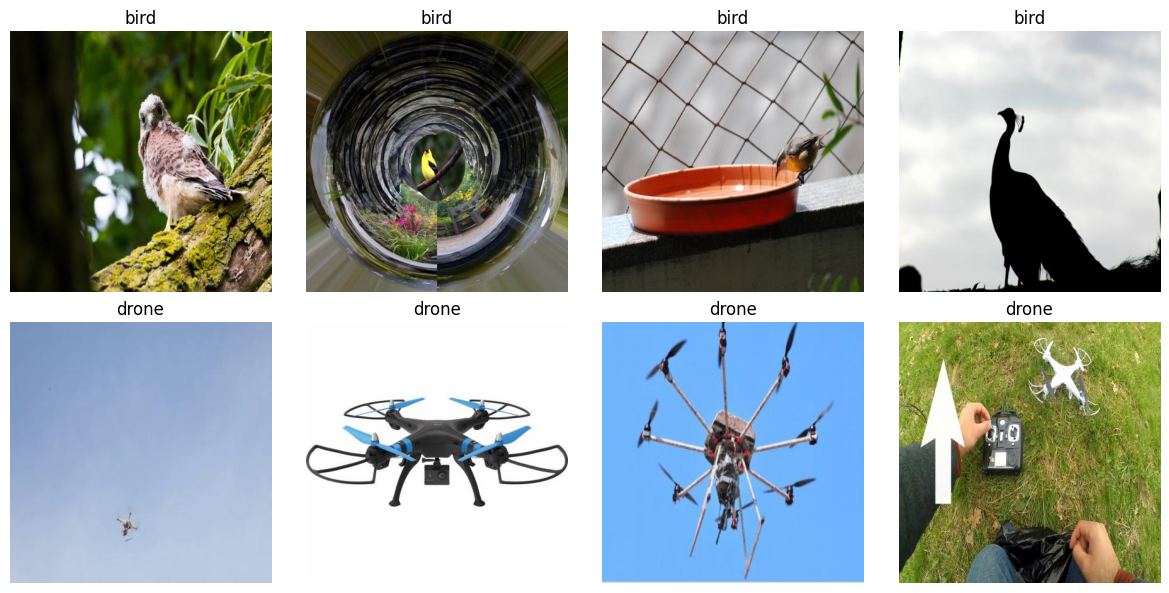

In [ ]:
# Cell 3: Dataset Inspection – Count images per class & visualize samples
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os # Ensure os is imported

def count_images(path):
    # Adjusted to count files directly under the 'bird' and 'drone' subdirectories
    bird_count = len(os.listdir(os.path.join(path, "bird"))) if os.path.exists(os.path.join(path, "bird")) else 0
    drone_count = len(os.listdir(os.path.join(path, "drone"))) if os.path.exists(os.path.join(path, "drone")) else 0
    return bird_count, drone_count

print("TRAIN set: birds =", count_images(CLASSIFICATION_TRAIN)[0], "drones =", count_images(CLASSIFICATION_TRAIN)[1])
print("VALID set: birds =", count_images(CLASSIFICATION_VAL)[0], "drones =", count_images(CLASSIFICATION_VAL)[1])
print("TEST set: birds =", count_images(CLASSIFICATION_TEST)[0], "drones =", count_images(CLASSIFICATION_TEST)[1])

# Visualize sample images
fig, axes = plt.subplots(2, 4, figsize=(12,6))
for i, cls in enumerate(["bird", "drone"]):
    folder = os.path.join(CLASSIFICATION_TRAIN, cls)
    if os.path.exists(folder):
        samples = os.listdir(folder)[:4]
        for j, img_name in enumerate(samples):
            img_path = os.path.join(folder, img_name)
            img = mpimg.imread(img_path)
            axes[i, j].imshow(img)
            axes[i, j].set_title(cls)
            axes[i, j].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 4: Data Preprocessing & Augmentation for Classification
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    CLASSIFICATION_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['bird', 'drone']
)

val_generator = val_test_datagen.flow_from_directory(
    CLASSIFICATION_VAL,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['bird', 'drone']
)

test_generator = val_test_datagen.flow_from_directory(
    CLASSIFICATION_TEST,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['bird', 'drone'],
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
Class indices: {'bird': 0, 'drone': 1}


In [ ]:
# Cell 5: Build Custom CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_custom_cnn(input_shape=(224,224,3)):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(256, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy', 'precision', 'recall'])
    return model

custom_cnn = build_custom_cnn()
custom_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265,729 (73.49 MB)

 Trainable params: 19,264,769 (73.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# Cell 6: Build Transfer Learning Model (MobileNetV2) – you can change to ResNet50 or EfficientNetB0
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation='sigmoid')(x)

transfer_model = Model(inputs=base_model.input, outputs=predictions)
transfer_model.compile(optimizer=Adam(learning_rate=0.0001),
                       loss='binary_crossentropy',
                       metrics=['accuracy', 'precision', 'recall'])
transfer_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Cell 8: Evaluation – Confusion Matrix, Classification Report, Accuracy/Loss Plots
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, test_gen, model_name):
    # Reset the test_gen before predicting to ensure predictions align with true labels
    test_gen.reset()
    y_pred_probs = model.predict(test_gen)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    y_true = test_gen.classes

    cm = confusion_matrix(y_true, y_pred)
    print(f"\n{model_name} - Classification Report:\n",
          classification_report(y_true, y_pred, target_names=['bird','drone']))

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bird','drone'], yticklabels=['bird','drone'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()
    return y_true, y_pred

# Evaluate Custom CNN
# Check if history_cnn exists and if custom_cnn was trained successfully
if 'history_cnn' in locals() and custom_cnn:
    evaluate_model(custom_cnn, test_generator, "Custom CNN")
else:
    print("Custom CNN training history or model not found. Skipping evaluation.")

# Evaluate Transfer Model (after fine-tuning)
# Check if history_finetune exists and if transfer_model was trained successfully
if 'history_finetune' in locals() and transfer_model:
    evaluate_model(transfer_model, test_generator, "Transfer Learning (MobileNetV2)")
else:
    print("Transfer Learning model training history or model not found. Skipping evaluation.")


# Plot training history
def plot_history(history, title):
    if history is None: # Added check for None history object
        print(f"No history to plot for {title}")
        return
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    axes[0].plot(history.history['accuracy'], label='Train Acc')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].legend()
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} - Loss')
    axes[1].legend()
    plt.show()

plot_history(history_cnn, "Custom CNN")
plot_history(history_transfer, "Transfer Learning (initial)")
plot_history(history_finetune, "Transfer Learning (fine-tuned)")

In [ ]:
# Cell 9: Model Comparison & Save Best Model
import time

def training_time_estimate(model, generator, epochs=3):
    start = time.time()
    model.fit(generator, epochs=epochs, verbose=0)
    return time.time() - start

print("Estimating training times (3 epochs)...")

# Only estimate and evaluate if models were trained
custom_acc = 0
transfer_acc = 0

if 'custom_cnn' in locals() and custom_cnn:
    print("Custom CNN time:", training_time_estimate(custom_cnn, train_generator, 3), "seconds")
    custom_acc = custom_cnn.evaluate(test_generator, verbose=0)[1]
    print(f"Custom CNN Test Accuracy: {custom_acc:.4f}")
else:
    print("Custom CNN model not found. Skipping time estimation and evaluation.")

if 'transfer_model' in locals() and transfer_model:
    print("Transfer model time:", training_time_estimate(transfer_model, train_generator, 3), "seconds")
    transfer_acc = transfer_model.evaluate(test_generator, verbose=0)[1]
    print(f"Transfer Learning Test Accuracy: {transfer_acc:.4f}")
else:
    print("Transfer Learning model not found. Skipping time estimation and evaluation.")


# Save the better model (assuming transfer learning performs better)
if custom_acc > 0 or transfer_acc > 0: # Only save if at least one model was evaluated
    if transfer_acc >= custom_acc:
        transfer_model.save('best_classifier.h5')
        print("Saved transfer model as best_classifier.h5")
    else:
        custom_cnn.save('best_classifier.h5')
        print("Saved custom CNN as best_classifier.h5")
else:
    print("No models were successfully trained or evaluated, skipping saving 'best_classifier.h5'.")

In [ ]:
# Cell 10: Optional – YOLOv8 Object Detection Training
# First, create data.yaml file for YOLOv8
yaml_content = f"""
path: {YOLO_ROOT}
train: train/images
val: val/images
test: test/images

nc: 1
names: ['drone']
"""

with open('data.yaml', 'w') as f:
    f.write(yaml_content)
print("data.yaml created:", yaml_content)

# Train YOLOv8 model (uncomment to run – may take time)
from ultralytics import YOLO

# Load pretrained YOLOv8n model
yolo_model = YOLO('yolov8n.pt')

# Train the model
# results = yolo_model.train(
#     data='data.yaml',
#     epochs=50,
#     imgsz=640,
#     batch=16,
#     patience=10,
#     device=0  # use GPU if available
# )

# If you want to skip training, you can load a pretrained YOLO model
# For demonstration, we'll just show validation (assuming you have trained it)
# To validate a trained model:
# yolo_model = YOLO('runs/detect/train/weights/best.pt')
# metrics = yolo_model.val()
# print(f"mAP50-95: {metrics.box.map:.4f}")

print("YOLOv8 training script ready – uncomment to run.")

In [ ]:
# Cell 11: Run Inference with YOLOv8 (example on a test image)
# This assumes you have a trained YOLO model or you can use a sample image
from ultralytics import YOLO
import cv2

# If you have a trained model, load it:
# yolo_model = YOLO('runs/detect/train/weights/best.pt')

# For demonstration, we'll use the base pretrained model (not fine-tuned on your dataset)
yolo_model = YOLO('yolov8n.pt')

# Pick an image from your test set (change path accordingly)
sample_img_path = os.path.join(CLASSIFICATION_TEST, 'drone', os.listdir(os.path.join(CLASSIFICATION_TEST, 'drone'))[0])
if os.path.exists(sample_img_path):
    results = yolo_model(sample_img_path)
    # Display result
    from IPython.display import Image as IPImage
    results[0].save('yolo_output.jpg')
    IPImage('yolo_output.jpg')
else:
    print("Sample image not found. Please provide a valid path.")

In [ ]:
# Cell 12: Prepare Streamlit App Code (to be run locally, not in Colab)
# This cell generates a Python script that you can download and run with "streamlit run app.py"
streamlit_code = """
import streamlit as st
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image

# Load the saved classification model
@st.cache_resource
def load_classifier():
    return load_model('best_classifier.h5')

model = load_classifier()
class_names = ['bird', 'drone']

st.title("Bird vs Drone Classifier")
st.write("Upload an image to classify whether it contains a **bird** or a **drone**.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    img = Image.open(uploaded_file)
    st.image(img, caption='Uploaded Image', use_column_width=True)

    # Preprocess
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    pred_prob = model.predict(img_array)[0][0]
    pred_class = class_names[0] if pred_prob < 0.5 else class_names[1]
    confidence = pred_prob if pred_class == 'drone' else 1 - pred_prob

    st.write(f"**Prediction:** {pred_class}")
    st.write(f"**Confidence:** {confidence:.2%}")

    # Optional: YOLOv8 detection (if you have the model file)
    # from ultralytics import YOLO
    # yolo_model = YOLO('best_yolo.pt')
    # results = yolo_model(img)
    # st.image(results[0].plot(), caption='YOLO Detection')
"""

with open('app.py', 'w') as f:
    f.write(streamlit_code)
print("Streamlit app script saved as 'app.py'. Download it and run locally with: streamlit run app.py")

In [ ]:
# Cell 13: Download Best Model and Streamlit App (to local machine)
from google.colab import files
files.download('best_classifier.h5')
files.download('app.py')
print("Model and app script downloaded. You can now deploy on your local machine or Streamlit Cloud.")

In [ ]:
import os

if os.path.exists('best_classifier.h5'):
    print("'best_classifier.h5' exists in the current directory.")
else:
    print("'best_classifier.h5' does not exist in the current directory.")

'best_classifier.h5' does not exist in the current directory.


In [11]:
# 🚀 Aerial Object Classification & Detection (Colab Ready)

# =============================
# 1. Install Dependencies
# =============================
!pip install tensorflow opencv-python matplotlib scikit-learn ultralytics

# =============================
# 2. Imports
# =============================
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix

# =============================
# 3. Upload Dataset (ZIP)
# =============================
from google.colab import files
uploaded = files.upload()

# Unzip dataset
import zipfile

extracted_base_path = '/content/dataset'
os.makedirs(extracted_base_path, exist_ok=True)

for file_key in uploaded.keys():
    zip_file_path = os.path.join('/content', file_key)
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_base_path)

# =============================
# 4. Data Preprocessing
# =============================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Corrected paths based on observed dataset structure:
# The zip files extract into a structure like /content/dataset/train/train, /content/dataset/valid/valid, etc.
train_dir = os.path.join(extracted_base_path, 'train', 'train')
val_dir = os.path.join(extracted_base_path, 'valid', 'valid')
test_dir = os.path.join(extracted_base_path, 'test', 'test')

print(f"Set train_dir: {train_dir}")
print(f"Set val_dir: {val_dir}")
print(f"Set test_dir: {test_dir}")

print("Train path exists:", os.path.exists(train_dir))
print("Validation path exists:", os.path.exists(val_dir))
print("Test path exists:", os.path.exists(test_dir))

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['bird', 'drone'] # Explicitly define classes
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['bird', 'drone'] # Explicitly define classes
)

# =============================
# 5. Transfer Learning Model
# =============================
base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

# =============================
# 6. Training
# =============================
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=3)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

# =============================
# 7. Evaluation
# =============================
test_data = val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    classes=['bird', 'drone'] # Explicitly define classes
)

preds = model.predict(test_data)
y_pred = (preds > 0.5).astype(int)

print(classification_report(test_data.classes, y_pred))
print(confusion_matrix(test_data.classes, y_pred))

# =============================
# 8. Accuracy Graph
# =============================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# =============================
# 9. Save Model
# =============================
model.save('/content/best_model.h5')

# =============================
# 10. YOLOv8 (Optional)
# =============================
from ultralytics import YOLO

yolo_model = YOLO('yolov8n.pt')

# Train (update data.yaml path if needed)
# yolo_model.train(data='/content/data.yaml', epochs=20)

# =============================
# 11. Streamlit App (inside Colab)
# =============================

# Create app.py file
app_code = '''
import streamlit as st
import tensorflow as tf
from PIL import Image
import numpy as np

st.set_page_config(page_title="Bird vs Drone", layout="centered")

@st.cache_resource
def load_model():
    return tf.keras.models.load_model("/content/best_model.h5")

model = load_model()

st.title("Bird vs Drone Classifier")
st.write("Upload an image to classify.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg","jpeg","png"])

if uploaded_file:
    img = Image.open(uploaded_file).convert("RGB").resize((224,224))
    st.image(img, caption="Uploaded Image", use_column_width=True)
    arr = np.array(img)/255.0
    arr = np.expand_dims(arr, axis=0)

    pred = model.predict(arr)[0][0]

    if pred > 0.5:
        st.success(f"Prediction: Drone 🛸 (confidence: {pred:.2f})")
    else:
        st.success(f"Prediction: Bird 🐦 (confidence: {1-pred:.2f})")
'''

with open('/content/app.py', 'w') as f:
    f.write(app_code)

print("app.py created")

# =============================
# 12. Run Streamlit in Colab
# =============================
!pip install streamlit pyngrok

from pyngrok import ngrok

# Kill previous tunnels if any
try:
    ngrok.kill()
except:
    pass

# Start Streamlit app
!streamlit run /content/app.py &>/content/logs.txt &

# Expose via ngrok
public_url = ngrok.connect(8501)
print("Streamlit App URL:", public_url)

# =============================
# DONE ✅
# =============================
print("Training + Deployment Ready!")

Saving test-20260411T042710Z-3-001.zip to test-20260411T042710Z-3-001.zip
Saving train-20260411T042710Z-3-001.zip to train-20260411T042710Z-3-001.zip
Saving valid-20260411T042714Z-3-001.zip to valid-20260411T042714Z-3-001.zip
Set train_dir: /content/dataset/train/train
Set val_dir: /content/dataset/valid/valid
Set test_dir: /content/dataset/test/test
Train path exists: False
Validation path exists: False
Test path exists: False
Found 0 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

ValueError: The PyDataset has length 0

In [15]:
# =============================
# 5. Transfer Learning Model
# =============================
base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

# =============================
# 6. Training
# =============================
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=3)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

# =============================
# 7. Evaluation
# =============================
test_data = val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    classes=['bird', 'drone'] # Explicitly define classes
)

preds = model.predict(test_data)
y_pred = (preds > 0.5).astype(int)

print(classification_report(test_data.classes, y_pred))
print(confusion_matrix(test_data.classes, y_pred))

# =============================
# 8. Accuracy Graph
# =============================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# =============================
# 9. Save Model
# =============================
model.save('/content/best_model.h5')

# =============================
# 10. YOLOv8 (Optional)
# =============================
from ultralytics import YOLO

yolo_model = YOLO('yolov8n.pt')

# Train (update data.yaml path if needed)
# yolo_model.train(data='/content/data.yaml', epochs=20)

# =============================
# 11. Streamlit App (inside Colab)
# =============================

# Create app.py file
app_code = '''
import streamlit as st
import tensorflow as tf
from PIL import Image
import numpy as np

st.set_page_config(page_title="Bird vs Drone", layout="centered")

@st.cache_resource
def load_model():
    return tf.keras.models.load_model("/content/best_model.h5")

model = load_model()

st.title("Bird vs Drone Classifier")
st.write("Upload an image to classify.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg","jpeg","png"])

if uploaded_file:
    img = Image.open(uploaded_file).convert("RGB").resize((224,224))
    st.image(img, caption="Uploaded Image", use_column_width=True)
    arr = np.array(img)/255.0
    arr = np.expand_dims(arr, axis=0)

    pred = model.predict(arr)[0][0]

    if pred > 0.5:
        st.success(f"Prediction: Drone 🛸 (confidence: {pred:.2f})")
    else:
        st.success(f"Prediction: Bird 🐦 (confidence: {1-pred:.2f})")
'''

with open('/content/app.py', 'w') as f:
    f.write(app_code)

print("app.py created")

# =============================
# 12. Run Streamlit in Colab
# =============================
!pip install streamlit pyngrok

from pyngrok import ngrok

# Kill previous tunnels if any
try:
    ngrok.kill()
except:
    pass

# Start Streamlit app
!streamlit run /content/app.py &>/content/logs.txt &

# Expose via ngrok
public_url = ngrok.connect(8501)
print("Streamlit App URL:", public_url)

# =============================
# DONE ✅
# =============================
print("Training + Deployment Ready!")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

ValueError: The PyDataset has length 0

In [14]:
import os

print("Contents of extracted_base_path:")
for root, dirs, files in os.walk(extracted_base_path):
    level = root.replace(extracted_base_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')


Contents of extracted_base_path:
dataset/
    test/
        bird/
            1c1952447d5d322c_jpg.rf.2c276c0f1c62451a7f8ef7f529e5bd3e.jpg
            104f1bdceabcf7ba_jpg.rf.0b9745f785acd2ddb1dc562b1403efb3.jpg
            16d4bc0874355c5a_jpg.rf.ba9278dcc9aa9e8a4b07d9b019161ce4.jpg
            06c85a56c7076a15_jpg.rf.8f607bbd05e085ecb0bcb8951a025186.jpg
            0df304b575cc0852_jpg.rf.60869438d34e69a930ef9cf937fa1d49.jpg
            1d2f913c05774d26_jpg.rf.f155652e89f370389993e8cceaaa4329.jpg
            0078fb03bcd9e384_jpg.rf.66436160110f8810912498e51e53f8ea.jpg
            0228e26f56a4f301_jpg.rf.99d883577d4466fe2e9d94cb690c4f3c.jpg
            0771007407c702a3_jpg.rf.73b4404df3a0f827bba8cded342d5f30.jpg
            1a7ee31df5960b05_jpg.rf.a8e519daa2fb787deec5315ecfd3f470.jpg
            1952b6934d50fd02_jpg.rf.5f378117becb6708a8fed80658484ccf.jpg
            006ce62a72df4dd4_jpg.rf.8f8e7b6e9a26a01be91ea1b7dc4011d2.jpg
            0be2066ba7ba8632_jpg.rf.03ba8ce8242a6b5ce14345

In [6]:
import os
print(os.listdir('.'))

['.config', '05e678fd75733516_jpg.rf.ecb3f3eb23c6e9161a0c7080d04c027c.jpg', '00570e9f0f6e1db1_jpg.rf.74c4b8f9a5883a03baf79e60f1a2dacb.jpg', '0225a1017604cf02_jpg.rf.5e71cec6ebde559b806286777cf074d4.jpg', '0c5461bfec73d113_jpg.rf.104f9943ccc3bd6ad31b016e2567f5b9.jpg', '0cb0ea49e108ee6a_jpg.rf.ca299f025560664d66229f440b0d247a.jpg', '000b4796f7fb05df_jpg.rf.424af2aea307cff3f4ecfc227b17493e.jpg', '1880b1ca0c4cfaad_jpg.rf.9a52f3618273f3fb8b1cf600dc044275.jpg', '1ae479bd81dcb688_jpg.rf.67dd2b4053f14b09fb9be0efd38d4caa.jpg', '0193b7da5f07941c_jpg.rf.0cb532664d5fe994cf6cc276ab3fdef3.jpg', '088f3c6b4d2a2f8d_jpg.rf.4d1caea7aa4ea92634ad00dfd915dfa6.jpg', '.ipynb_checkpoints', '0383304ff8116348_jpg.rf.559bfe871f095383b5c77d01764c143b.jpg', '16c125d36ee2d7f8_jpg.rf.bc93c57a195b11322733da7bcc7d6ed1.jpg', '009b4309855b6434_jpg.rf.72b991f9c3da4624b1601061db1dbbcf.jpg', '08e83650e928c1c3_jpg.rf.c828a38f31746006c548915f2f57c750.jpg', '198504fef1dae1ab_jpg.rf.447fffaeab8ff2244c5057afc5325516.jpg', '1c9d0

In [5]:
print('Files uploaded:', uploaded.keys())

Files uploaded: dict_keys(['00b407bebbaa93bc_jpg.rf.6b35a71e438747929bd250c39ebdaf39.jpg', '00d159d96abc5f86_jpg.rf.cc82ba87a8e7300833f7e4e5cabf0bd8.jpg', '0a56bcc5600a295d_jpg.rf.425eb1a53b0d44173499e28cb03d63f9.jpg', '0ae99d11858f87d6_jpg.rf.cef318351bf1c702b1be2599cde719a8.jpg', '0b84162e85786028_jpg.rf.f6f7fc1579401d7f0f86c43e6781ea35.jpg', '0bf24557876fdfa6_jpg.rf.27398cf8333509e79f976a597fea7f55.jpg', '0d1adb09f1d07007_jpg.rf.5f2873c85d60f1a39241a45fd06c8673.jpg', '0de51e4c7c280c1a_jpg.rf.f0a1377411b1011670d56931b42f3217.jpg', '0e8cbe6aa0822efd_jpg.rf.b709535ff1bb6a93718b7487ff0934f2.jpg', '01ec322024fc754e_jpg.rf.c7ca7edfe12fab97953daf3ca1dd7993.jpg', '1b1c95de35ecd331_jpg.rf.82c92433c75a9ef6a22d6afed815d8a3.jpg', '1bb03c6a4ff649b1_jpg.rf.2d0609eecd22e01fd16d50e6de03cf95.jpg', '1bb7e81e627477ab_jpg.rf.a3c32a36b3ea53523ee4d286c04e26be.jpg', '1bb275d319e8a4bc_jpg.rf.12a91d2331150bafe02dab784227bc86.jpg', '02be53642dc6cca0_jpg.rf.265fa321785a1f3a9ada666622385a58.jpg', '005e061db776

In [10]:
!pip install gradio

In [16]:
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

# Load model
model = tf.keras.models.load_model('/content/best_model.h5')

# Prediction function
def predict_image(image):
    img = image.resize((224, 224))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)[0][0]

    if prediction > 0.5:
        label = "Drone 🛸"
        confidence = float(prediction)
    else:
        label = "Bird 🐦"
        confidence = float(1 - prediction)

    return label, confidence

# Custom CSS for professional look
custom_css = """
body {
    background-color: #0f172a;
}
h1 {
    text-align: center;
    color: #38bdf8;
}
"""

with gr.Blocks(css=custom_css) as app:

    gr.Markdown("# ✈️ Aerial Object Detection System")
    gr.Markdown("### Upload an aerial image to classify it as **Bird 🐦 or Drone 🛸**")

    with gr.Row():
        with gr.Column():
            input_image = gr.Image(type="pil", label="Upload Image")

            submit_btn = gr.Button("🔍 Analyze", variant="primary")

        with gr.Column():
            output_label = gr.Textbox(label="Prediction")
            output_confidence = gr.Slider(
                0, 1, step=0.01, label="Confidence Score"
            )

    submit_btn.click(
        fn=predict_image,
        inputs=input_image,
        outputs=[output_label, output_confidence]
    )

    gr.Markdown("---")
    gr.Markdown("💡 Built using Deep Learning & Computer Vision")

# Launch app
app.launch(share=True)

/tmp/ipykernel_12758/4273641702.py:37: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css) as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8ffc1471e0cd1c3edd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [17]:
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

# Load model
model = tf.keras.models.load_model('/content/best_model.h5')

# Prediction function
def predict_image(image):
    img = image.resize((224, 224))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)[0][0]

    if prediction > 0.5:
        label = "Drone 🛸"
        confidence = float(prediction)
    else:
        label = "Bird 🐦"
        confidence = float(1 - prediction)

    return label, confidence

# Custom CSS for professional look
custom_css = """
body {
    background-color: #0f172a;
}
h1 {
    text-align: center;
    color: #38bdf8;
}
"""

with gr.Blocks(css=custom_css) as app:

    gr.Markdown("# ✈️ Aerial Object Detection System")
    gr.Markdown("### Upload an aerial image to classify it as **Bird 🐦 or Drone 🛸**")

    with gr.Row():
        with gr.Column():
            input_image = gr.Image(type="pil", label="Upload Image")

            submit_btn = gr.Button("🔍 Analyze", variant="primary")

        with gr.Column():
            output_label = gr.Textbox(label="Prediction")
            output_confidence = gr.Slider(
                0, 1, step=0.01, label="Confidence Score"
            )

    submit_btn.click(
        fn=predict_image,
        inputs=input_image,
        outputs=[output_label, output_confidence]
    )

    gr.Markdown("---")
    gr.Markdown("💡 Built using Deep Learning & Computer Vision")

# Launch app
app.launch(share=True)

/tmp/ipykernel_12758/4273641702.py:37: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css) as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a72f92bea42cf72b05.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [18]:
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

# Load model
model = tf.keras.models.load_model('/content/best_model.h5')

# Prediction function
def predict_image(image):
    # Ensure RGB
    image = image.convert("RGB")

    # Resize & normalize
    img = image.resize((224, 224))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict
    prediction = model.predict(img)[0][0]

    # 🔥 Adjust threshold (important)
    threshold = 0.6   # try 0.6 instead of 0.5

    # 🔥 Swap labels if needed
    if prediction > threshold:
        label = "Drone 🛸"
        confidence = float(prediction)
    else:
        label = "Bird 🐦"
        confidence = float(1 - prediction)

    return f"{label}", confidence

# UI
custom_css = """
body { background-color: #0f172a; }
h1 { text-align: center; color: #38bdf8; }
"""

with gr.Blocks(css=custom_css) as app:

    gr.Markdown("# ✈️ Aerial Object Detection System")
    gr.Markdown("### Upload an aerial image to classify it as Bird 🐦 or Drone 🛸")

    with gr.Row():
        with gr.Column():
            input_image = gr.Image(type="pil", label="Upload Image")
            submit_btn = gr.Button("🔍 Analyze", variant="primary")

        with gr.Column():
            output_label = gr.Textbox(label="Prediction")
            output_confidence = gr.Slider(0, 1, step=0.01, label="Confidence")

    submit_btn.click(
        fn=predict_image,
        inputs=input_image,
        outputs=[output_label, output_confidence]
    )

    gr.Markdown("---")
    gr.Markdown("💡 Built using Deep Learning & Computer Vision")

app.launch(share=True)

/tmp/ipykernel_12758/2708942019.py:41: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css) as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a0f719a23097601c62.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
